In [28]:
import pandas as pd
edu = pd.read_csv('files/ch02/educ_figdp_1_Data.csv',na_values=':',usecols = ["TIME","GEO","Value"])
edu

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95
...,...,...,...
379,2007,Finland,5.90
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85


In [29]:
edu.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [30]:
edu.tail()

,TIME,GEO,Value
379,2007,Finland,5.90
380,2008,Finland,6.10
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


In [31]:
edu.describe()

,TIME,Value
count,384.000000,361.000000
mean,2005.500000,5.203989
std,3.456556,1.021694
min,2000.000000,2.880000
25%,2002.750000,4.620000
50%,2005.500000,5.060000
75%,2008.250000,5.660000
max,2011.000000,8.810000


In [32]:
edu['Value']

0       NaN
1       NaN
2      5.00
3      5.03
4      4.95
       ... 
379    5.90
380    6.10
381    6.81
382    6.85
383    6.76
Name: Value, Length: 384, dtype: float64

In [33]:
edu[10:14]

,TIME,GEO,Value
10,2010,European Union (28 countries),5.41
11,2011,European Union (28 countries),5.25
12,2000,European Union (27 countries),4.91
13,2001,European Union (27 countries),4.99


In [34]:
edu.loc[90:94, ['TIME','GEO']]

,TIME,GEO
90,2006,Belgium
91,2007,Belgium
92,2008,Belgium
93,2009,Belgium
94,2010,Belgium


In [35]:
edu[edu['Value'] > 6.5].tail() 

,TIME,GEO,Value
286,2010,Malta,6.74
287,2011,Malta,7.96
381,2009,Finland,6.81
382,2010,Finland,6.85
383,2011,Finland,6.76


In [36]:
edu[edu['Value'].isnull()].head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
36,2000,Euro area (18 countries),NaN
37,2001,Euro area (18 countries),NaN
48,2000,Euro area (17 countries),NaN


In [37]:
edu.max(axis = 0)

TIME      2011
GEO      Spain
Value     8.81
dtype: object

In [38]:
print("Pandas max function:", edu['Value'].max())
print("Python max function:", max(edu['Value']))

Pandas max function: 8.81
Python max function: nan


In [39]:
s = edu['Value']/100
s.head()

0       NaN
1       NaN
2    0.0500
3    0.0503
4    0.0495
Name: Value, dtype: float64

In [40]:
import numpy as np

In [41]:
s = edu['Value'].apply(np.sqrt)
s.head()

0         NaN
1         NaN
2    2.236068
3    2.242766
4    2.224860
Name: Value, dtype: float64

In [42]:
s = edu['Value'].apply(lambda d: d**2)
s.head()

0        NaN
1        NaN
2    25.0000
3    25.3009
4    24.5025
Name: Value, dtype: float64

In [43]:
edu['ValueNorm'] = edu['Value']/edu['Value'].max()
edu.tail()

,TIME,GEO,Value,ValueNorm
379,2007,Finland,5.90,0.669694
380,2008,Finland,6.10,0.692395
381,2009,Finland,6.81,0.772985
382,2010,Finland,6.85,0.777526
383,2011,Finland,6.76,0.767310


In [44]:
edu.drop('ValueNorm', axis=1,inplace = True)
edu.head()

,TIME,GEO,Value
0,2000,European Union (28 countries),NaN
1,2001,European Union (28 countries),NaN
2,2002,European Union (28 countries),5.00
3,2003,European Union (28 countries),5.03
4,2004,European Union (28 countries),4.95


In [45]:
edu['Value']

0       NaN
1       NaN
2      5.00
3      5.03
4      4.95
       ... 
379    5.90
380    6.10
381    6.81
382    6.85
383    6.76
Name: Value, Length: 384, dtype: float64

In [46]:
edu[edu['Value'] > 6.5].head()

,TIME,GEO,Value
93,2009,Belgium,6.57
94,2010,Belgium,6.58
95,2011,Belgium,6.55
120,2000,Denmark,8.28
121,2001,Denmark,8.44


In [47]:
s = edu['Value'].apply(lambda d: d*4)
s.tail()

379    23.60
380    24.40
381    27.24
382    27.40
383    27.04
Name: Value, dtype: float64

In [55]:
# 1. Create a new row as a DataFrame
new_row = pd.DataFrame([{"Time": 2000, "Value": 5.00, "GEO": 'a'}])

# 2. Use concat to join them
edu = pd.concat([edu, new_row], ignore_index=True)

edu.tail()

,TIME,GEO,Value,Time
380,2008.0,Finland,6.10,NaN
381,2009.0,Finland,6.81,NaN
382,2010.0,Finland,6.85,NaN
383,2011.0,Finland,6.76,NaN
384,NaN,a,5.00,2000.0


In [56]:
edu.drop(max(edu.index),axis=0,inplace= True)
edu.tail()

,TIME,GEO,Value,Time
379,2007.0,Finland,5.90,NaN
380,2008.0,Finland,6.10,NaN
381,2009.0,Finland,6.81,NaN
382,2010.0,Finland,6.85,NaN
383,2011.0,Finland,6.76,NaN


In [62]:
# Drop rows where the "Value" column is NaN
eduDrop = edu.dropna(how='any',subset=["Value"])
eduDrop.head()

,TIME,GEO,Value,Time
2,2002.0,European Union (28 countries),5.00,NaN
3,2003.0,European Union (28 countries),5.03,NaN
4,2004.0,European Union (28 countries),4.95,NaN
5,2005.0,European Union (28 countries),4.92,NaN
6,2006.0,European Union (28 countries),4.91,NaN


In [66]:
eduFilled=edu.fillna(value={"Value": 0})
eduFilled.head()

,TIME,GEO,Value,Time
0,2000.0,European Union (28 countries),0.00,NaN
1,2001.0,European Union (28 countries),0.00,NaN
2,2002.0,European Union (28 countries),5.00,NaN
3,2003.0,European Union (28 countries),5.03,NaN
4,2004.0,European Union (28 countries),4.95,NaN


In [67]:
eduTimeFilled= edu.fillna(value = {"Time":0})
eduTimeFilled.head()

,TIME,GEO,Value,Time
0,2000.0,European Union (28 countries),NaN,0.0
1,2001.0,European Union (28 countries),NaN,0.0
2,2002.0,European Union (28 countries),5.00,0.0
3,2003.0,European Union (28 countries),5.03,0.0
4,2004.0,European Union (28 countries),4.95,0.0


In [68]:
edu.sort_values(by='Value',ascending=False,inplace=True)
edu.head()

,TIME,GEO,Value,Time
130,2010.0,Denmark,8.81,NaN
131,2011.0,Denmark,8.75,NaN
129,2009.0,Denmark,8.74,NaN
122,2002.0,Denmark,8.44,NaN
121,2001.0,Denmark,8.44,NaN


In [69]:
edu.sort_index(axis=0,ascending=False,inplace=True)
edu.head()

,TIME,GEO,Value,Time
383,2011.0,Finland,6.76,NaN
382,2010.0,Finland,6.85,NaN
381,2009.0,Finland,6.81,NaN
380,2008.0,Finland,6.10,NaN
379,2007.0,Finland,5.90,NaN


In [70]:
group =edu[["GEO","Value"]].groupby('GEO').mean()
group.head()

,Value
GEO,
Austria,5.618333
Belgium,6.189091
Bulgaria,4.093333
Cyprus,7.023333
Czech Republic,4.168333


In [71]:
filtered_data=edu[edu["TIME"]>2005]
pivedu=pd.pivot_table(filtered_data,values='Value',index=['GEO'],columns=['TIME'])
pivedu.head()

TIME,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0
GEO,,,,,,
Austria,5.40,5.33,5.47,5.98,5.91,5.80
Belgium,5.98,6.00,6.43,6.57,6.58,6.55
Bulgaria,4.04,3.88,4.44,4.58,4.10,3.82
Cyprus,7.02,6.95,7.45,7.98,7.92,7.87
Czech Republic,4.42,4.05,3.92,4.36,4.25,4.51


In [73]:
pivedu.loc[['Spain','Portugal'],[2006,2011]]

TIME,2006.0,2011.0
GEO,,
Spain,4.26,4.82
Portugal,5.07,5.27


In [79]:
pivedu=pivedu.drop([
    'Euro area (13 countries)',
    'Euro area (15 countries)',
    'Euro area (17 countries)',
    'Euro area (18 countries)',
    'European Union (25 countries)',
      'European Union (27 countries)',
      'European Union (28 countries)'],axis=0,errors='ignore')
pivedu=pivedu.rename(index={'Germany (until 1990 former territory of the FRG)':'Germany'})
pivedu= pivedu.dropna()
pivedu.rank(ascending=False,method='first').head()

TIME,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0
GEO,,,,,,
Austria,10.0,7.0,11.0,7.0,8.0,8.0
Belgium,5.0,4.0,3.0,4.0,5.0,5.0
Bulgaria,21.0,21.0,20.0,20.0,22.0,22.0
Cyprus,2.0,2.0,2.0,2.0,2.0,3.0
Czech Republic,19.0,20.0,21.0,21.0,20.0,19.0


In [82]:
totalSum=pivedu.sum(axis=1)
totalSum.rank(ascending=False,method='dense').sort_values().head()


GEO
Denmark    1.0
Cyprus     2.0
Finland    3.0
Malta      4.0
Belgium    5.0
dtype: float64

<Axes: title={'center': 'Total Values for Country'}, xlabel='GEO'>

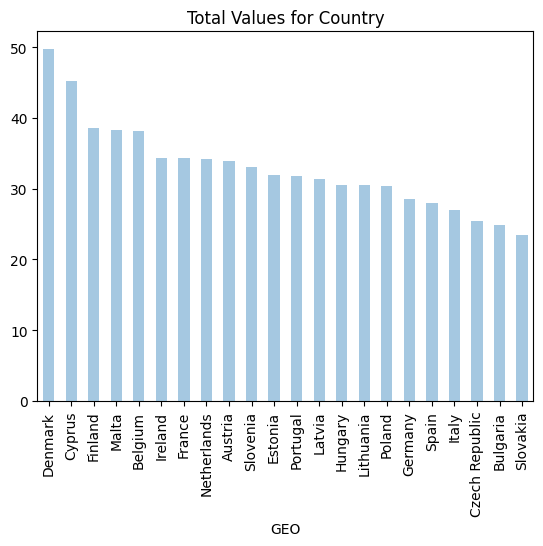

In [83]:
totalSum =pivedu.sum(axis=1).sort_values(ascending=False)
totalSum.plot(kind='bar',style='b',alpha=0.4,title="Total Values for Country")

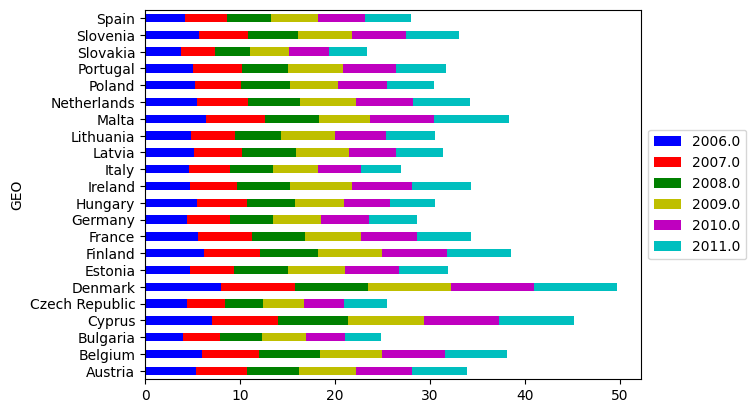

In [84]:
my_colors=['b','r','g','y','m','c']
ax=pivedu.plot(kind='barh',stacked=True,color=my_colors)
ax.legend(loc='center left',bbox_to_anchor=(1,.5))